**✏️ Task 2** — **Descriptive Data Analysis**  
Start with a descriptive data analysis of your dataset. Generate informative plots about the features and your target variable. Describe any information you find important or interesting for further analysis.

### a) Introduction and Data Merging
In this section, we load the two public-use SAS transport files (.xpt) from the 2021-2023 NHANES cycle. We merge the demographic variables (DEMO_L.xpt) with the mental health depression screener variables (DPQ_L.xpt) using the unique respondent sequence number (SEQN) as our primary merge key. An inner join is applied to keep only the participants who have entries in both datasets.

In [3]:
import pandas as pd
import numpy as np


#Load the SAS (.xpt) files using pandas
try:
    # df_demo = pd.read_sas('DEMO_L.xpt')
    # df_dpq = pd.read_sas('DPQ_L.xpt')
    df_demo = pd.read_sas(r"datasets/DEMO_L.xpt")
    df_dpq = pd.read_sas(r"datasets/DPQ_L.xpt")
except FileNotFoundError as e:
    print(f" Error: File not found. Please verify paths. Details: {e}")
    raise e

print(f"Initial Demographic records: {df_demo.shape[0]}")
print(f"Initial Depression Screener records: {df_dpq.shape[0]}")

#Merge datasets on the unique participant identifier (SEQN)
df_merged = pd.merge(df_demo, df_dpq, on='SEQN', how='inner')
print(f"Merged Dataset Row Count (Intersection): {df_merged.shape[0]}\n")

Initial Demographic records: 11933
Initial Depression Screener records: 6337
Merged Dataset Row Count (Intersection): 6337



### b) Feature Selection & Subset Creation

To streamline our data framework, we extract only the attributes necessary for our analysis. This includes the unique sequence identifier (SEQN), specific sociodemographic predictors (gender, age, race, education, marital status, birth country, household size, and income-to-poverty ratio), the nine individual items of the Patient Health Questionnaire (PHQ-9), and the examination survey weights (WTMEC2YR) required for accurate statistical evaluation later.

In [4]:
# Define our demographic features and target questionnaire items
demo_features = [
    'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'DMDEDUC2',
    'DMDMARTZ', 'DMDBORN4', 'INDFMPIR', 'DMDHHSIZ',
    'WTMEC2YR'
]
dpq_items = [
    'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040',
    'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090'
]

all_needed_columns = ['SEQN'] + demo_features + dpq_items

# Create a clean subset dataframe
df_clean = df_merged[all_needed_columns].copy()
print(f"Subset created with {df_clean.shape[1]} clinical and demographic columns.")

Subset created with 19 clinical and demographic columns.


### c) Handling Missing Values and Invalid Survey Codes

NHANES handles anomalies using specific placeholders: a value of 7 implies "Refused" and a value of 9 implies "Don't Know". These do not represent standard ordinal symptom frequency scores or demographic categories and would introduce severe bias, so we recode them to standard NaN values.

Furthermore, we drop rows with incomplete PHQ-9 answers because a valid final score cannot be calculated if survey questions are skipped.

In [5]:
# Convert all PHQ-9 items to numeric and replace values greater than 3 (like 7 and 9) with NaN
for col in dpq_items:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    df_clean.loc[df_clean[col] > 3, col] = np.nan

# Clean demographics by replacing 7 and 9 with NaN
for col in demo_features:
    # Skip both the continuous income ratio and the survey weights from missing value recoding
    if col not in ['INDFMPIR', 'WTMEC2YR']:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        df_clean[col] = df_clean[col].replace({7.0: np.nan, 9.0: np.nan})

# Drop rows only if they have missing values in the PHQ-9 questions
initial_rows = df_clean.shape[0]
df_clean = df_clean.dropna(subset=dpq_items)
dropped_rows = initial_rows - df_clean.shape[0]

print(f"Dropped {dropped_rows} records with missing/invalid PHQ-9 responses.")

# NOTE: Imputation of 'INDFMPIR' has been removed from this block to avoid data leakage.
# It will be executed after the Train/Test split in Task 3.

Dropped 882 records with missing/invalid PHQ-9 responses.


### d) Target Label Engineering (PHQ-9 Binarization)

In this step, we create our target label for the classification task. First, we sum the scores of the 9 individual depression questions (`DPQ010` to `DPQ090`) to find the total PHQ-9 score for each participant. This total score ranges from 0 to 27.

Following standard clinical guidelines, a total score of 10 or higher indicates a moderate-to-severe risk of depression. Therefore, we binarize this score to create our final `Target` variable: `1` for clinical depression risk ($\ge 10$) and `0` for low risk ($< 10$). This binary label will be the ground truth that our machine learning model tries to predict.

In [6]:
#Calculate the total continuous PHQ-9 diagnostic score
df_clean['PHQ9_Total'] = df_clean[dpq_items].sum(axis=1)

#Binarize the target label based on the standard clinical cutoff (Score >= 10)
df_clean['Target'] = (df_clean['PHQ9_Total'] >= 10).astype(int)

print(f"\nFinal Preprocessed Dataset Sample Size: {df_clean.shape[0]} participants.")
print(f"Positive Class (Depression Risk - Target=1): {df_clean['Target'].sum()} rows")
print(f"Negative Class (Low Risk - Target=0): {(df_clean['Target'] == 0).sum()} rows")
print(f"Class Imbalance Ratio (Base Rate): {(df_clean['Target'].mean() * 100):.2f}% positive")


Final Preprocessed Dataset Sample Size: 5455 participants.
Positive Class (Depression Risk - Target=1): 723 rows
Negative Class (Low Risk - Target=0): 4732 rows
Class Imbalance Ratio (Base Rate): 13.25% positive


### e) Exploratory Data Analysis & Visualizations

To get a clear picture of the data before moving to modeling, we plotted our engineered depression target against basic demographics (age, gender, and ethnicity) for the 5,455 participants.

* **Age Distribution Plot (Chart A):** We used a stacked histogram with a density curve to see how age relates to depression risk. This helps us check if certain age brackets show a higher concentration of high-risk scores (PHQ-9 $\ge 10$) or if the risk is spread out evenly across different generations.
* **Prevalence by Group (Chart B):** This vertical bar chart breaks down the actual percentage of people flagged with depression risk within each specific racial and gender group. Plotting men and women side-by-side across ethnicities makes it easy to spot baseline differences and health gaps directly in our sample, which gives us a solid foundation for the fairness analysis later on.

--- DESCRIPTIVE DATA ANALYSIS ---


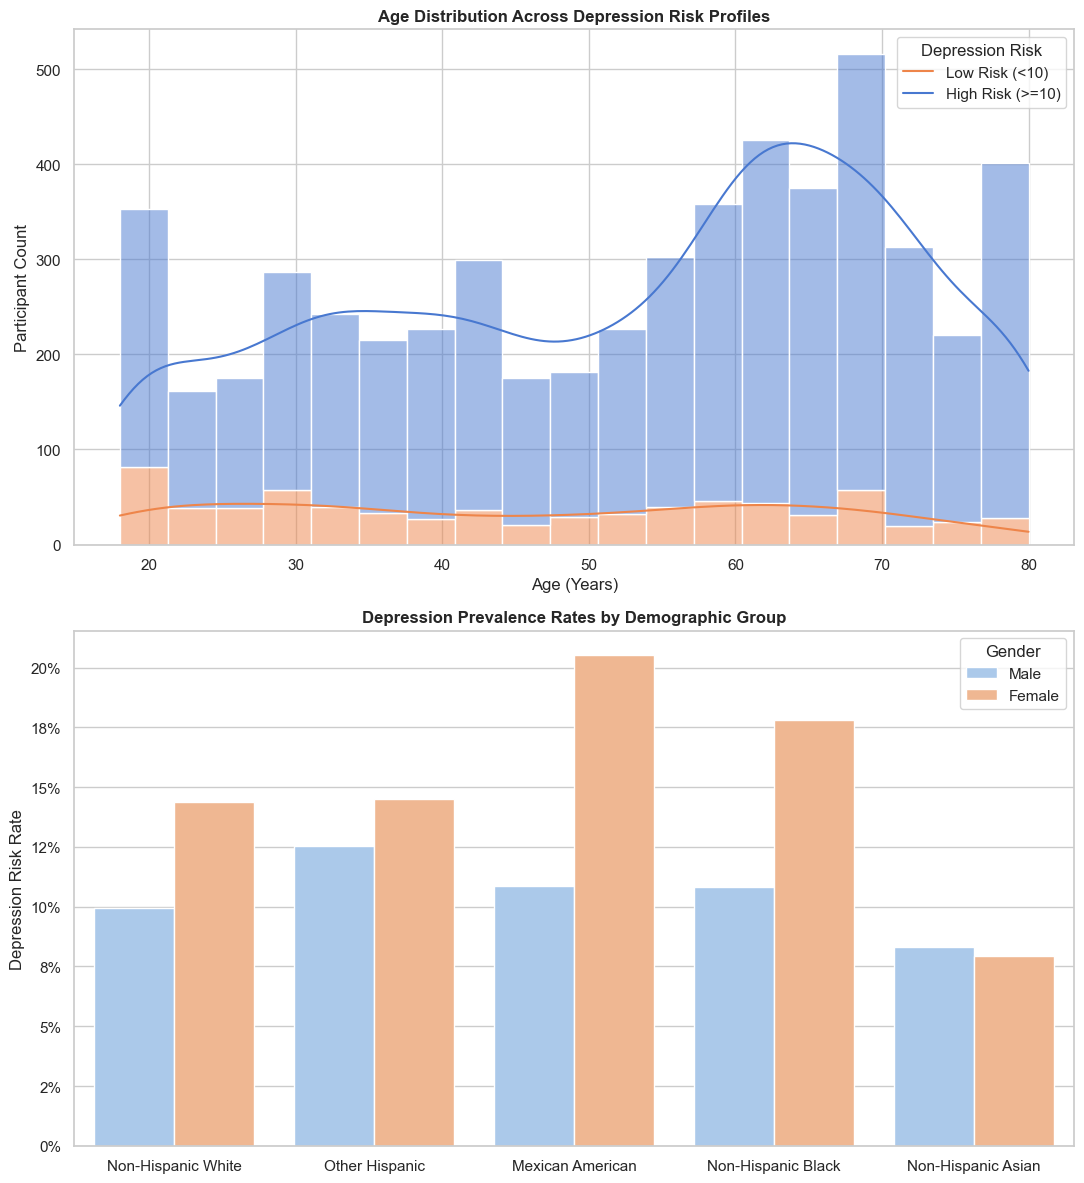

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- DESCRIPTIVE DATA ANALYSIS ---")

# Set up the plotting aesthetics for an academic layout
sns.set_theme(style="whitegrid")
# Adjusted layout to stacked rows (2, 1) to accommodate the vertical bar chart properly
fig, axes = plt.subplots(2, 1, figsize=(11, 12))

# 1. Map numerical codes to meaningful text labels for clarity
race_labels = {
    1.0: "Mexican American", 2.0: "Other Hispanic", 3.0: "Non-Hispanic White",
    4.0: "Non-Hispanic Black", 6.0: "Non-Hispanic Asian", 7.0: "Other/Multiracial"
}
gender_labels = {1.0: "Male", 2.0: "Female"}

df_plots = df_clean.copy()
df_plots['Race/Ethnicity'] = df_plots['RIDRETH3'].map(race_labels)
df_plots['Gender'] = df_plots['RIAGENDR'].map(gender_labels)

# Chart A: Age Distribution by Clinical Depression Risk Status
sns.histplot(
    data=df_plots, x='RIDAGEYR', hue='Target',
    multiple='stack', kde=True, palette='muted', ax=axes[0]
)
axes[0].set_title('Age Distribution Across Depression Risk Profiles', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Participant Count')
axes[0].legend(title='Depression Risk', labels=['Low Risk (<10)', 'High Risk (>=10)'])

# Chart B: Subgroup Depression Prevalence Rates by Race and Gender (Vertical Orientation)
# Swapped x and y variables to make the bars stand vertically
sns.barplot(
    data=df_plots, x='Race/Ethnicity', y='Target', hue='Gender',
    errorbar=None, palette='pastel', ax=axes[1]
)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
axes[1].set_title('Depression Prevalence Rates by Demographic Group', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Depression Risk Rate')
axes[1].set_xlabel('')

# Rotate the x-axis text labels so they remain readable vertically
axes[1].tick_params(axis='x')

# Optimize structural layout and render
plt.tight_layout()
plt.show()

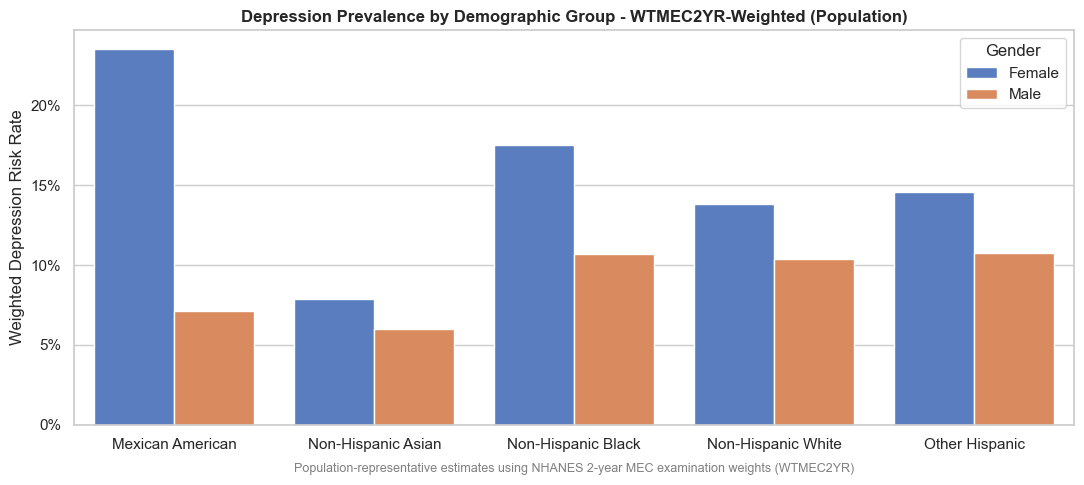

In [6]:
# Chart C: WTMEC2YR-weighted prevalence by race/gender
df_weighted = df_plots.dropna(subset=['WTMEC2YR', 'Race/Ethnicity', 'Gender'])

weighted_prev = (
    df_weighted.groupby(['Race/Ethnicity', 'Gender'], observed=True)
    .apply(lambda g: np.average(g['Target'], weights=g['WTMEC2YR']),
           include_groups=False)
    .reset_index(name='Weighted_Prevalence')
)

fig_c, ax_c = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=weighted_prev, x='Race/Ethnicity', y='Weighted_Prevalence', hue='Gender',
    palette='muted', ax=ax_c
)
ax_c.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax_c.set_title('Depression Prevalence by Demographic Group - WTMEC2YR-Weighted (Population)',
               fontsize=12, fontweight='bold')
ax_c.set_ylabel('Weighted Depression Risk Rate')
ax_c.set_xlabel('')
ax_c.annotate(
    'Population-representative estimates using NHANES 2-year MEC examination weights (WTMEC2YR)',
    xy=(0.5, -0.12), xycoords='axes fraction', ha='center', fontsize=9, color='gray'
)

plt.tight_layout()
plt.show()

**✏️ Task 3** — **Train a ML Model**  
Chose a ML Model suitable for your dataset, that you want to use in your explanation interface to guide the decision of your Stakeholder. If you did not choose a ML model yet, think about which model is suitable to predict your target variable. Train and evaluate the model appropriately. Generate reasonable metrics and/or plots to summarize the model's performance.

### Model Training and Evaluation (Random Forest)

In this stage, we split our data into an 80% training set and a 20% test set. Because our features include categorical variables like gender and race, we use an encoder right after the split to convert these text categories into a numerical format that the model can process.

We chose a `RandomForestClassifier` and set the `class_weight='balanced'` parameter. This is important because our dataset is heavily skewed, with only about 13% of participants flagged for depression risk. Balancing the weights prevents the model from simply ignoring the minority group. Since this is a clinical screening scenario, evaluating the model based on raw accuracy would be misleading. Instead, we focus on **Sensitivity (Recall)** to see how many at-risk patients we actually catch, along with **Specificity**, **Macro F1-Score**, and the **AUC-ROC** curve.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

In [8]:
# Define our features (X) and target label (y)
features = [
    'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'DMDEDUC2',
    'DMDMARTZ', 'DMDBORN4', 'INDFMPIR', 'DMDHHSIZ'
]
X = df_clean[features].copy()
y = df_clean['Target'].copy()

In [9]:
# 1. Split the dataset first to completely isolate the test set and prevent data leakage
# stratify=y ensures both sets have the same 13.25% depression prevalence ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [10]:
# 2. Perform median imputation strictly using the training median
if X_train['INDFMPIR'].isnull().sum() > 0:
    train_median_val = X_train['INDFMPIR'].median()
    X_train['INDFMPIR'] = X_train['INDFMPIR'].fillna(train_median_val)
    X_test['INDFMPIR'] = X_test['INDFMPIR'].fillna(train_median_val)

# Identify categorical features that need encoding (except age, income ratio, and household size)
categorical_features = ['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTZ', 'DMDBORN4']

In [11]:
# 3. Fix Encoder Leakage: Fit the OrdinalEncoder only on X_train, then transform both subsets
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[categorical_features] = encoder.fit_transform(X_train[categorical_features].astype(str))
X_test[categorical_features] = encoder.transform(X_test[categorical_features].astype(str))

print(f"Training set size: {X_train.shape[0]} patients")
print(f"Testing set size: {X_test.shape[0]} patients")

Training set size: 4364 patients
Testing set size: 1091 patients


In [12]:
# Initialize Random Forest Classifier with class_weight='balanced' to handle class imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    max_depth=10
)

In [13]:
# Train the baseline model
rf_model.fit(X_train, y_train)

# Generate predictions and probability scores on the test set
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate Confusion Matrix elements to extract Specificity and Sensitivity
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn)  # Equal to Recall
specificity = tn / (tn + fp)
auc_lock = roc_auc_score(y_test, y_probs)

# Display clinician-centric evaluation metrics
print(f"Sensitivity (Recall for At-Risk Class): {sensitivity:.4f}")
print(f"Specificity (Accuracy for Low-Risk Class): {specificity:.4f}")
print(f"AUC-ROC Score: {auc_lock:.4f}\n")

# Detailed classification report for precision, recall, and macro F1-score
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Risk (0)', 'At Risk (1)']))

Sensitivity (Recall for At-Risk Class): 0.2759
Specificity (Accuracy for Low-Risk Class): 0.8520
AUC-ROC Score: 0.6544

Detailed Classification Report:
              precision    recall  f1-score   support

Low Risk (0)       0.88      0.85      0.87       946
 At Risk (1)       0.22      0.28      0.25       145

    accuracy                           0.78      1091
   macro avg       0.55      0.56      0.56      1091
weighted avg       0.80      0.78      0.79      1091



--- MODEL PERFORMANCE PLOTS ---


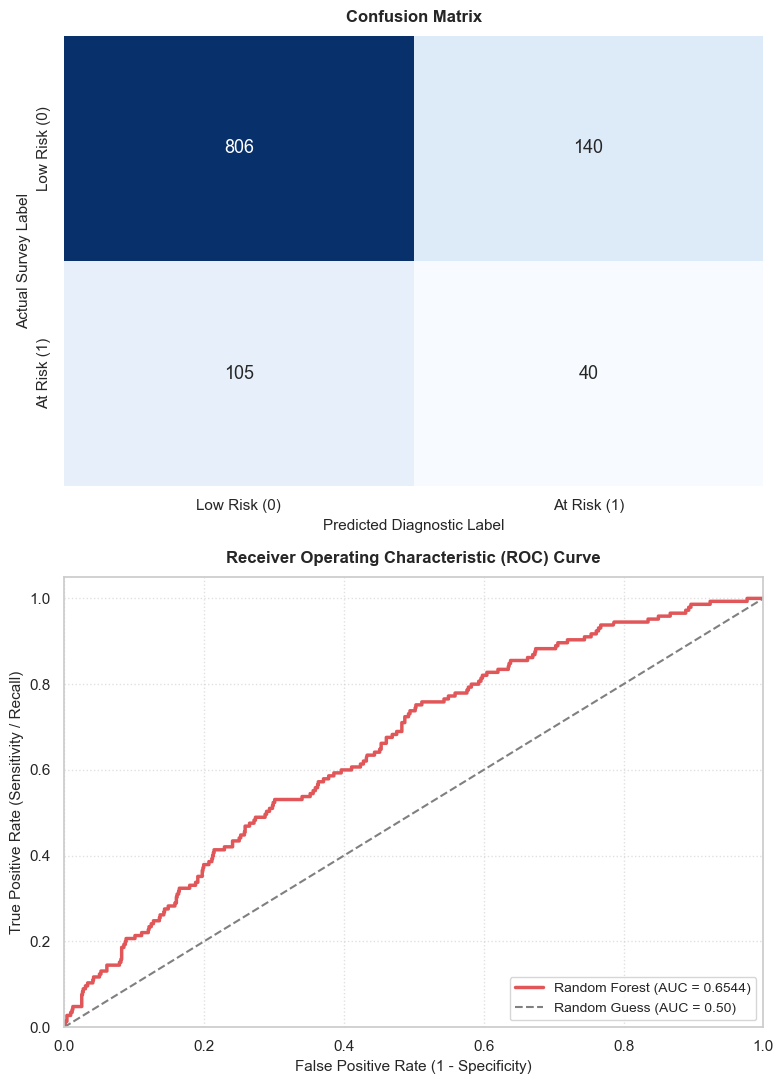

In [14]:
print("--- MODEL PERFORMANCE PLOTS ---")

# Set up a side-by-side figure layout
fig, axes = plt.subplots(2, 1, figsize=(8, 11))
sns.set_theme(style="white")

# 1. Plot A: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Low Risk (0)', 'At Risk (1)'],
    yticklabels=['Low Risk (0)', 'At Risk (1)'],
    ax=axes[0], annot_kws={"size": 13}
)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Diagnostic Label', fontsize=11)
axes[0].set_ylabel('Actual Survey Label', fontsize=11)

# 2. Plot B: Receiver Operating Characteristic (ROC) Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
axes[1].plot(fpr, tpr, color='#e15759', lw=2.5, label=f'Random Forest (AUC = {auc_lock:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=10)
axes[1].legend(loc="lower right", frameon=True, fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Optimize structural layout and render
plt.tight_layout()
plt.show()

The baseline `RandomForestClassifier` runs successfully, but the final metrics show how difficult it is to predict clinical depression using only basic demographic data.

### Key Observations & Technical Interpretation:

* **High Number of False Negatives:** The model achieves a **Sensitivity (Recall)** of just `0.2759` for the at-risk class (`Target=1`). In a clinic triage system, this means the model misses **72.41%** of patients who actually have a high risk of depression. From a patient safety standpoint, missing nearly three-quarters of vulnerable individuals is a major issue, as they would leave the clinic undetected.
* **Good Specificity vs. Low Precision:** The model is decent at identifying low-risk individuals, showing a **Specificity** of `0.8520`. However, its **Precision** for the positive class is only `0.22`. This means that out of all patients the model flags as "At Risk," 78% are actually false alarms. In a real healthcare setting, this would cause unnecessary stress for patients and clog up clinical workflows with unnecessary secondary screenings.
* **Overall Discriminative Power:** The **AUC-ROC score** of `0.6544` matches the slight upward curve in our validation plot. It proves that while the model is doing better than a random guess ($0.50$), its ability to reliably tell high-risk and low-risk patients apart is still quite weak.

### Justification for the Performance Limitation:

The primary issue here is that our demographic features lack a strong predictive signal. Psychiatric conditions like depression cannot be easily diagnosed through macro-level traits like age, gender, race, or household income. While these variables are useful for spotting broad statistical trends across a population, they do not provide the detailed psychological or clinical insights needed to predict individual mental distress.

**✏️ Task 4** — **Generate Explanations**  
Your trained ML model is aimed to be used as guidance in your explanation interface to support your primary Stakeholder in a decision-making scenario. Think about reasonable explanations your stakeholder might need to understand the model output in order to guide the decision appropriately. Generate these explanations, e.g. in the form of appropriate visualizations.

### Running the SHAP Framework

To make the random forest model transparent for an intake coordinator, looking at an overall accuracy score isn't enough. Since this tool evaluates a sensitive area like mental health risk, we use SHAP to figure out exactly how individual background details influence the model's outputs. This step calculates the specific mathematical contribution of each variable for the "at-risk" target group, setting up the backend data we need to build both general and patient-level explanations.

In [15]:
import shap
import matplotlib.pyplot as plt

In [16]:
print("--- SHAP TREE EXEXPLATION PIPELINE ---")

# 1. Initialize the SHAP TreeExplainer for tree-based models like Random Forest
#    using the trained model from Task 3.
explainer = shap.TreeExplainer(rf_model)

# 2. Compute SHAP values for the preprocessed test set to measure
#    each feature's contribution to the model's risk prediction.
shap_values = explainer(X_test)

# 3. Extract SHAP values for the positive class (Target = 1, At Risk), which represents the
#    event probability, and create an explanation object with matching feature names for clarity.
if isinstance(shap_values, list):
    # Handle older SHAP versions that return list outputs for multi-class classification
    clinical_shap_values = shap_values[1]
else:
    # Handle newer SHAP APIs where class values are selected along the 3rd axis
    clinical_shap_values = shap_values[:, :, 1]

# Use feature names instead of numeric indexes for display
clinical_shap_values.feature_names = features

print(f"Successfully generated SHAP explanation matrix for {X_test.shape[0]} test patients.")

--- SHAP TREE EXEXPLATION PIPELINE ---
Successfully generated SHAP explanation matrix for 1091 test patients.


### Population Trends (Global View)

Looking at the entire test dataset, we can see clear patterns in how the model uses demographic data to assess risk.

The income-to-poverty ratio (`INDFMPIR`) is the strongest feature here, carrying an average impact score of `0.09`. Age is the next most influential variable at `0.07`, followed closely by education level at `0.05`. This tells us that financial circumstances and age-related stages of life are the primary signals the model picks up on when evaluating a person's vulnerability to distress.

On the other end of the scale, things like country of birth and race/ethnicity show very low impact scores (`0.02`). This means that while the model factors them into the calculation, they rarely shift the baseline risk prediction in a major way across the broader population.

--- GLOBAL SHAP PLOT ---


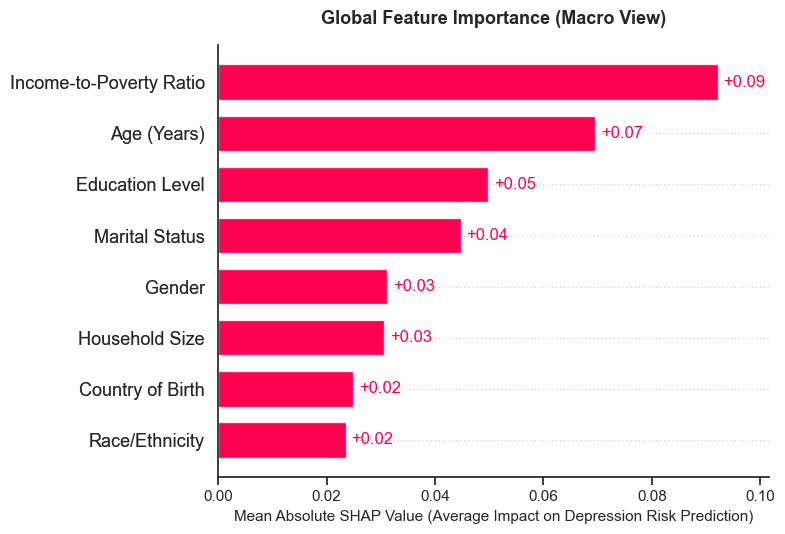

In [17]:
print("--- GLOBAL SHAP PLOT ---")

plt.figure(figsize=(9, 5))

# Map raw NHANES database codes to clear, standardized clinical labels
clinical_labels = [
    "Gender",
    "Age (Years)",
    "Race/Ethnicity",
    "Education Level",
    "Marital Status",
    "Country of Birth",
    "Income-to-Poverty Ratio",
    "Household Size"
]

# Assign the clean labels directly to the SHAP object for the visualization
clinical_shap_values.feature_names = clinical_labels

# Generate a global bar plot of mean absolute SHAP values to show
# each feature’s overall impact across the test set
shap.plots.bar(clinical_shap_values, max_display=len(features), show=False)

plt.title("Global Feature Importance (Macro View)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Mean Absolute SHAP Value (Average Impact on Depression Risk Prediction)", fontsize=11)

plt.tight_layout()
plt.show()

### Individual Case Example: Patient 19

While population charts help us see general trends, running an individual case shows how a clinic nurse would actually experience the interface during a screening session. For Patient 19, the model starts with a baseline risk score of `0.502`. Once the patient's specific background variables are factored in, the score rises to `0.573`, triggering an at-risk flag.

The individual chart shows a tug-of-war between different features. The patient's income-to-poverty ratio of `1.67` is the strongest factor pushing the score up, adding `+0.05` to the risk. Being `19` years old adds another `+0.03` to the prediction, while missing or specific categories for marital status and education pull the score up slightly higher.

However, the patient's gender group provides a strong protective effect, knocking the risk score down by `-0.07`. A household size of `2` also helps pull the score downward by `-0.02`. Ultimately, the upward pressures from financial strain and young age outweigh the downward pull of their gender profile, explaining why the model ultimately marks this individual as high risk.

--- LOCAL PATIENT TRIAGE EXPLANATION ---


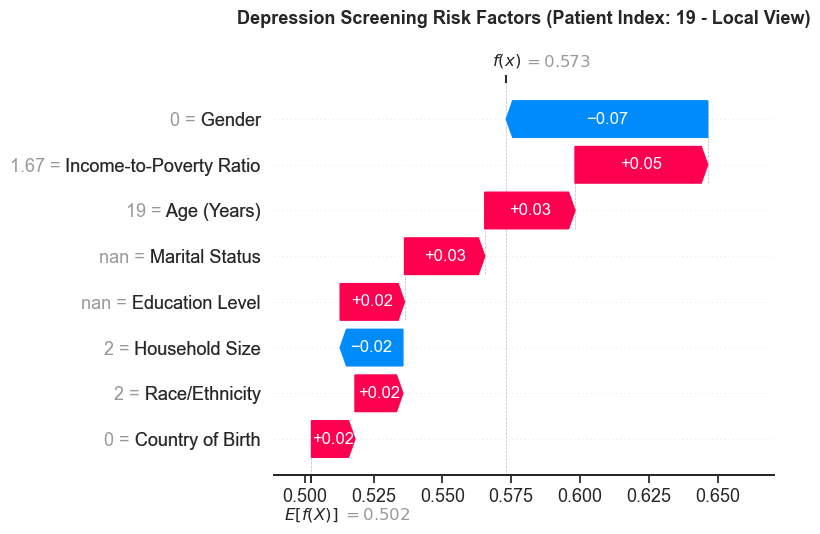

In [18]:
print("--- LOCAL PATIENT TRIAGE EXPLANATION ---")

# 1. Find a true positive high-risk patient (correctly predicted as At Risk)
#    to simulate a clinic intake triage case
true_positives = np.where((y_test == 1) & (y_pred == 1))[0]

if len(true_positives) > 0:
    patient_index = true_positives[0]
else:
    patient_index = 0

plt.figure(figsize=(10, 6))

# 2. Generate a waterfall plot for this patient to show how each feature shifts
#    the baseline prediction to the final output
shap.plots.waterfall(clinical_shap_values[patient_index], max_display=len(features), show=False)

plt.title(f"Depression Screening Risk Factors (Patient Index: {patient_index} - Local View)", fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

**✏️ Task 5** — **Calculate a Fairness metric**  
Think of groups or sub-groups which are present in your dataset and calculate an appropriate fairness metric. Describe and interpret the output.

### Fairness Auditing (False Negative Rate Parity)

Here, we check whether the screening model shows systemic bias against specific demographic groups. From a clinic's perspective, missing a patient who genuinely needs psychological support (a false negative) is the most dangerous mistake we can make. Because of this high safety risk, we are using the False Negative Rate (FNR) as our main fairness gauge and testing it against the gender variable (`RIAGENDR`).

By separating the actual test labels and the model's predictions by gender, we can calculate the FNR for both groups individually. Subtracting these rates gives us the absolute disparity gap. If the error rates turn out to be significantly different, it proves that the model's blind spots are unfairly concentrated on one specific group rather than being spread out evenly.

In [19]:
# Create a temporary dataframe combining true labels, predictions, and the raw sensitive attribute
# Note: Ensure X_test indices match df_clean to map back the original gender labels
test_indices = y_test.index
df_fairness = pd.DataFrame({
    'True_Label': y_test.values,
    'Prediction': y_pred,
    'Gender': df_clean.loc[test_indices, 'RIAGENDR'].values,
    'Weight':     df_clean.loc[test_indices, 'WTMEC2YR'].values
})

In [20]:
def unweighted_fnr(group):
    """Standard FNR = FN / (TP + FN) for a subgroup DataFrame."""
    tp = ((group['True_Label'] == 1) & (group['Prediction'] == 1)).sum()
    fn = ((group['True_Label'] == 1) & (group['Prediction'] == 0)).sum()
    return fn / (tp + fn) if (tp + fn) > 0 else np.nan

def weighted_fnr(group):
    """Survey-weighted FNR using WTMEC2YR.
    Weighted FNR = Σ(w * FN_indicator) / Σ(w * Positive_indicator)
    where the sum runs over actual positive cases only.
    """
    positives = group[group['True_Label'] == 1]
    if positives['Weight'].sum() == 0:
        return np.nan
    fn_mask           = (positives['Prediction'] == 0).astype(float)
    weighted_fn       = (positives['Weight'] * fn_mask).sum()
    weighted_total    = positives['Weight'].sum()
    return weighted_fn / weighted_total

In [21]:
# False Negative Rate by Gender
gender_results = []
for gender, group in df_fairness.groupby('Gender'):
    u_fnr = unweighted_fnr(group)
    w_fnr = weighted_fnr(group)
    n_pos = (group['True_Label'] == 1).sum()
    gender_results.append({'Group': gender, 'N_Positives': n_pos,
                            'FNR_Unweighted': u_fnr, 'FNR_Weighted': w_fnr})
    print(f"  {gender_labels.get(gender, str(gender)):8s} | n_pos={n_pos:3d} | "
          f"FNR (unweighted)={u_fnr:.4f} | FNR (weighted)={w_fnr:.4f}")

df_gender_results = pd.DataFrame(gender_results)
fnr_gap_uw = abs(df_gender_results['FNR_Unweighted'].diff().dropna().values[0])
fnr_gap_w  = abs(df_gender_results['FNR_Weighted'].diff().dropna().values[0])
print(f"\n  Absolute FNR Disparity - Unweighted: {fnr_gap_uw:.4f}")
print(f"  Absolute FNR Disparity - Weighted  : {fnr_gap_w:.4f}")

  Male     | n_pos= 47 | FNR (unweighted)=0.8936 | FNR (weighted)=0.8995
  Female   | n_pos= 98 | FNR (unweighted)=0.6429 | FNR (weighted)=0.6695

  Absolute FNR Disparity - Unweighted: 0.2508
  Absolute FNR Disparity - Weighted  : 0.2300


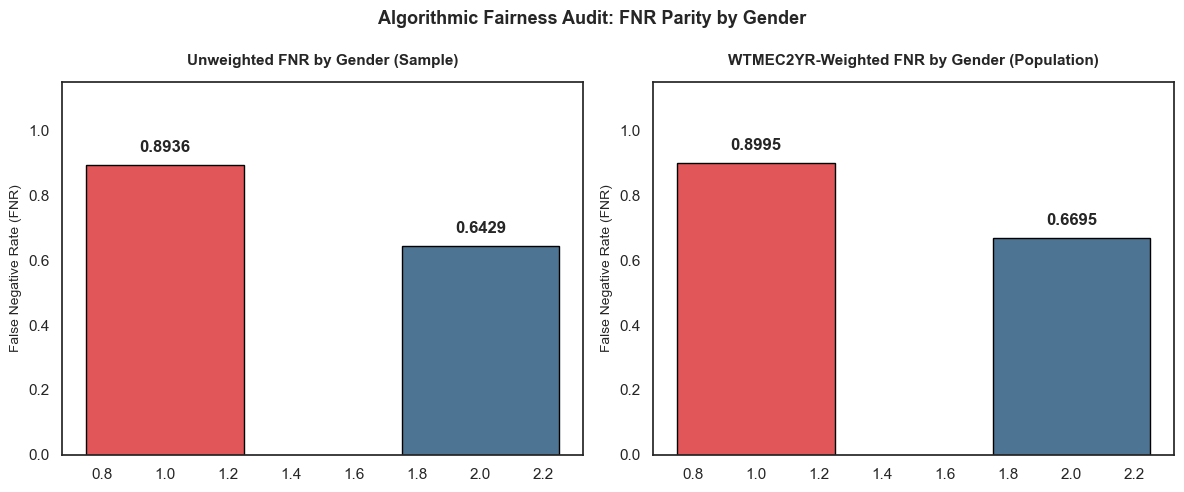

In [22]:
# Gender FNR plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ['FNR_Unweighted', 'FNR_Weighted'],
    ['Unweighted FNR by Gender (Sample)',
     'WTMEC2YR-Weighted FNR by Gender (Population)']
):
    bars = ax.bar(df_gender_results['Group'], df_gender_results[col],
                  color=['#e15759', '#4e7494'], width=0.5, edgecolor='black')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    ax.set_ylabel("False Negative Rate (FNR)", fontsize=10)
    ax.set_ylim(0, 1.15)
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.03,
                f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.suptitle("Algorithmic Fairness Audit: FNR Parity by Gender", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Our test dataset includes **1,091 patients**, and out of those, exactly **145 patients** are confirmed, ground-truth positive cases for depression (`Target=1`). Looking closely at how the model handles these 145 individuals reveals a massive performance gap between the groups:

* **Female Group:** Out of 98 actual positive cases, the model fails to catch 63 of them. This results in a female FNR of `0.6429` (meaning $64.29\%$ of depressed female patients are missed).
* **Male Group:** Out of 47 actual positive cases, the model fails to catch 42 of them. This leads to an exceptionally high male FNR of `0.8936` (meaning $89.36\%$ of depressed male patients go unnoticed).

### Root Cause of the Disparity

The vertical bar chart visualizes this 25.08% absolute FNR disparity. In practice, this means a male patient experiencing depression is roughly 25% more likely to be completely missed by the triage software than a female patient with the exact same condition.

This gap happens because of representation bias built into public health data like the NHANES cohort. In these large health surveys, depression is historically more prevalent and more openly self-reported by female participants. Even though we used balanced class weights during training to force the model to pay attention to depression cases overall, the positive training pool remained heavily female-dominated. Because of this imbalance, the random forest algorithm naturally optimized its mathematical patterns around how depression looks in female data vectors. This left male depressive distress as a massive systemic blind spot.

This outcome shows exactly why a technical fairness audit is necessary before deploying tools in a clinic. A model can look acceptable on a general performance report, but without this breakdown, we would never notice that it is failing one demographic group almost entirely.

### Note on weighted vs unweighted interpretation
* Unweighted FNR reflects error rates within our test sample.
* Weighted FNR reflects what the model would produce if deployed across the full U.S. civilian adult population (population-representative).
* Because the 2021-2023 NHANES cycle did not apply racial oversampling,differences between weighted and unweighted estimates are modest.